In [1]:
# Load all the libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("/content/marketing_data.xlsx")

In [4]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Month,Day,Year,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835,0,0,Jun,16,2014,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,57091,0,0,Jun,15,2014,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,67267,0,1,May,13,2014,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,32474,1,1,May,11,2014,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,21474,1,0,Apr,8,2014,...,2,7,1,0,0,0,0,1,0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476,0,1,Mar,7,2013,...,11,4,0,0,0,0,0,0,0,US
2236,5263,1977,2n Cycle,Married,31056,1,0,Jan,22,2013,...,3,8,0,0,0,0,0,0,0,SP
2237,22,1976,Graduation,Divorced,46310,1,0,Dec,3,2012,...,5,8,0,0,0,0,0,0,0,SP
2238,528,1978,Graduation,Married,65819,0,0,Nov,29,2012,...,10,3,0,0,0,0,0,0,0,IND


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2240 non-null   int64 
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Month                2240 non-null   object
 8   Day                  2240 non-null   int64 
 9   Year                 2240 non-null   int64 
 10  Recency              2240 non-null   int64 
 11  MntWines             2240 non-null   int64 
 12  MntFruits            2240 non-null   int64 
 13  MntMeatProducts      2240 non-null   int64 
 14  MntFishProducts      2240 non-null   int64 
 15  MntSweetProducts     2240 non-null   int64 
 16  MntGol

In [7]:
df["Age"] = 2025 - df['Year_Birth']

In [8]:
df["Age_Group"] = pd.cut(df["Age"],
                         bins = [0,18,40,60,123],
                         labels = ["Child","Adult", "Senior", "Old Age"])

In [9]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', ' Income ',
       'Kidhome', 'Teenhome', 'Month', 'Day', 'Year', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Age', 'Age_Group'],
      dtype='object')

In [10]:
df["Total_Spending"] = (df['MntWines']+df['MntFruits']+df['MntMeatProducts']+
                        df['MntFishProducts']+df['MntSweetProducts']+
                        df['MntGoldProds'])

In [11]:
df["Total_Reg_Purchase"]= (df['NumWebPurchases']+df['NumCatalogPurchases']+
                           df['NumStorePurchases'])

In [12]:
df["Purchase_Type"] = np.where(df['NumDealsPurchases'] > 0, "Deal", "Regular")

In [13]:
df.size

78400

In [14]:
# 1 Customer by education

In [15]:
df['Education'].unique()

array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)

In [18]:
df['Education'].value_counts()

,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Graduation'),
  Text(1, 0, 'PhD'),
  Text(2, 0, '2n Cycle'),
  Text(3, 0, 'Master'),
  Text(4, 0, 'Basic')])

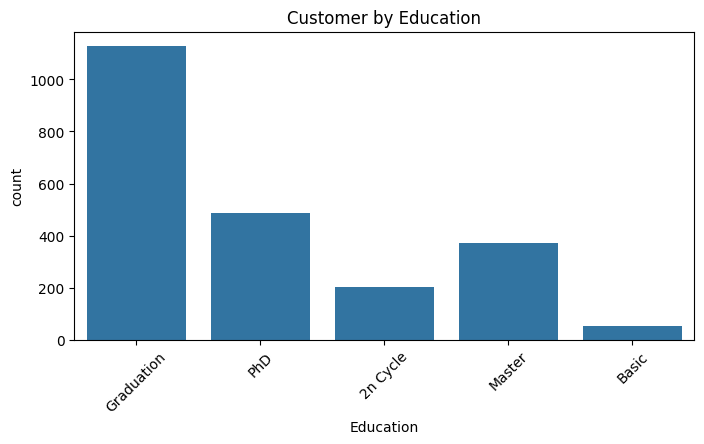

In [19]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Education')
plt.title("Customer by Education")
plt.xticks(rotation=45)

In [20]:
# 2 Customer by Marital Status

In [21]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,487
Divorced,232
Widow,77


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Divorced'),
  Text(1, 0, 'Single'),
  Text(2, 0, 'Married'),
  Text(3, 0, 'Together'),
  Text(4, 0, 'Widow')])

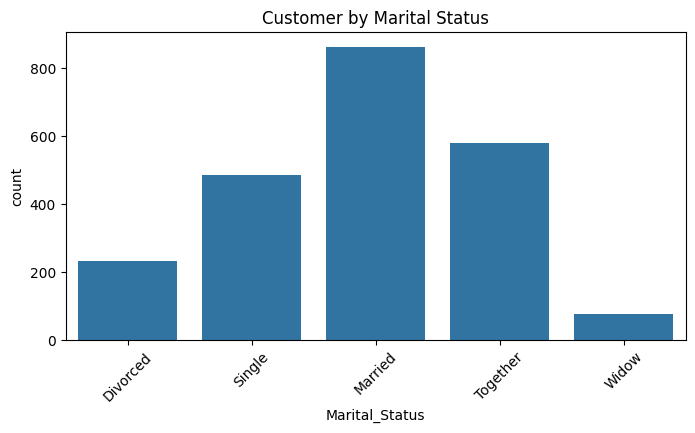

In [23]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Marital_Status')
plt.title("Customer by Marital Status")
plt.xticks(rotation=45)

In [24]:
# 3 Customer count by Country

In [25]:
df['Country'].value_counts()

,count
Country,
SP,1095
SA,337
CA,268
AUS,160
IND,148
GER,120
US,109
ME,3


Text(0.5, 1.0, 'Customer count by Country')

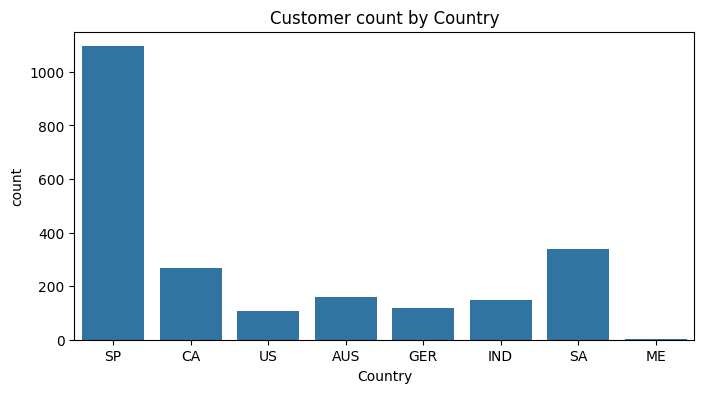

In [26]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Country')
plt.title("Customer count by Country")

In [27]:
# 4 Average Income by Education

In [28]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Day,Year,Recency,MntWines,MntFruits,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Age,Total_Spending,Total_Reg_Purchase
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,51687.459375,0.444196,0.506250,15.638393,2013.028125,49.109375,303.935714,26.302232,...,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375,56.194196,605.798214,12.537054
std,3246.662198,11.984069,25609.342730,0.538398,0.544538,8.790680,0.684554,28.962453,336.597393,39.773434,...,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391,11.984069,602.249288,7.205741
min,0.000000,1893.000000,0.000000,0.000000,0.000000,1.000000,2012.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,5.000000,0.000000
25%,2828.250000,1959.000000,34722.000000,0.000000,0.000000,8.000000,2013.000000,24.000000,23.750000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,48.000000,68.750000,6.000000
50%,5458.500000,1970.000000,51075.000000,0.000000,0.000000,16.000000,2013.000000,49.000000,173.500000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,396.000000,12.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,23.000000,2013.000000,74.000000,504.250000,33.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66.000000,1045.500000,18.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,31.000000,2014.000000,99.000000,1493.000000,199.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,132.000000,2525.000000,32.000000


In [31]:
df.groupby(['Education'])[' Income '].mean()

,Income
Education,
2n Cycle,46929.251232
Basic,20306.259259
Graduation,52205.800355
Master,52202.432432
PhD,55567.687243


/tmp/ipython-input-1708071119.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x="Education", y = " Income " , ci=False)


Text(0.5, 1.0, 'Average Income by Education')

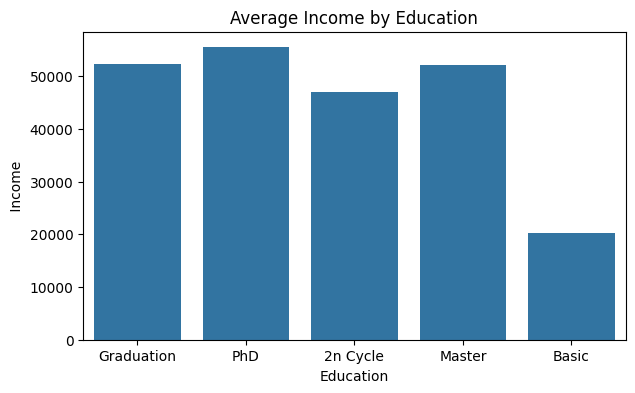

In [34]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="Education", y = " Income " , ci=False)
plt.title("Average Income by Education")

In [35]:
# 5 Average Income by Marital Status

In [36]:
df.groupby("Marital_Status")[' Income '].mean()

,Income
Marital_Status,
Divorced,52834.228448
Married,51305.910880
Single,50085.774127
Together,52602.915517
Widow,55748.025974


/tmp/ipython-input-615393285.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x="Marital_Status", y=' Income ', ci=False)


Text(0.5, 1.0, 'Average Income by Marital Status')

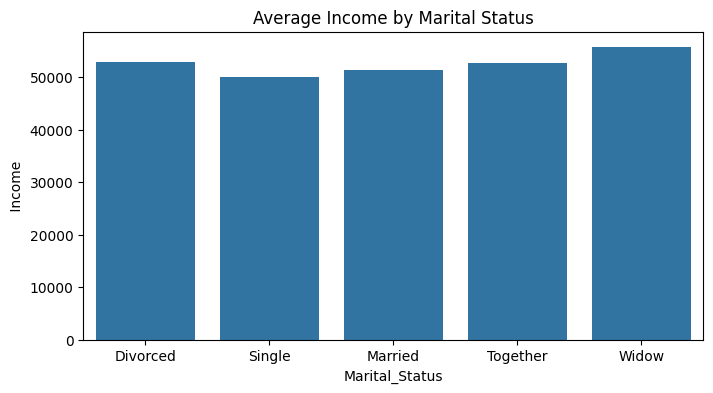

In [37]:
plt.figure(figsize=(8,4))
sns.barplot(data=df, x="Marital_Status", y=' Income ', ci=False)
plt.title("Average Income by Marital Status")

In [38]:
# 6 Kidhome Distribution

In [39]:
df['Kidhome'].value_counts()

,count
Kidhome,
0,1293
1,899
2,48


Text(0.5, 1.0, 'Kidhome Distribution')

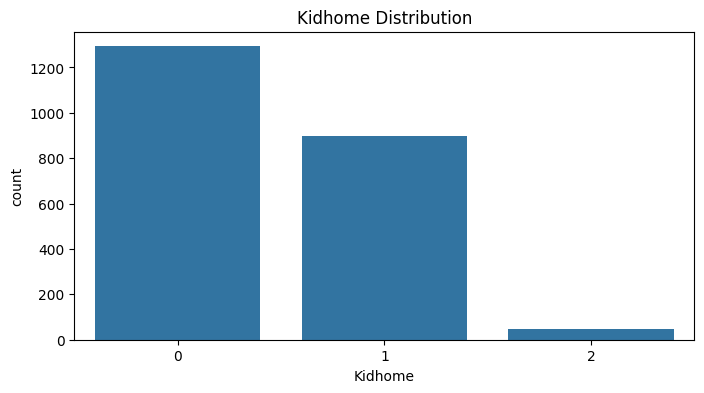

In [40]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Kidhome')
plt.title("Kidhome Distribution")

In [41]:
# 7 Teenhome Distribution

In [42]:
df['Teenhome'].value_counts()

,count
Teenhome,
0,1158
1,1030
2,52


Text(0.5, 1.0, 'Teenhome Distribution')

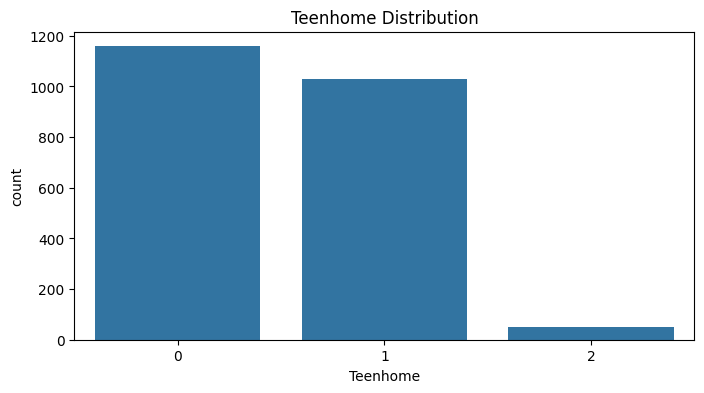

In [43]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Teenhome')
plt.title("Teenhome Distribution")